# Appendix: Empirical Analysis - Monroe et al. (2022)

In [4]:
import os
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, spearmanr

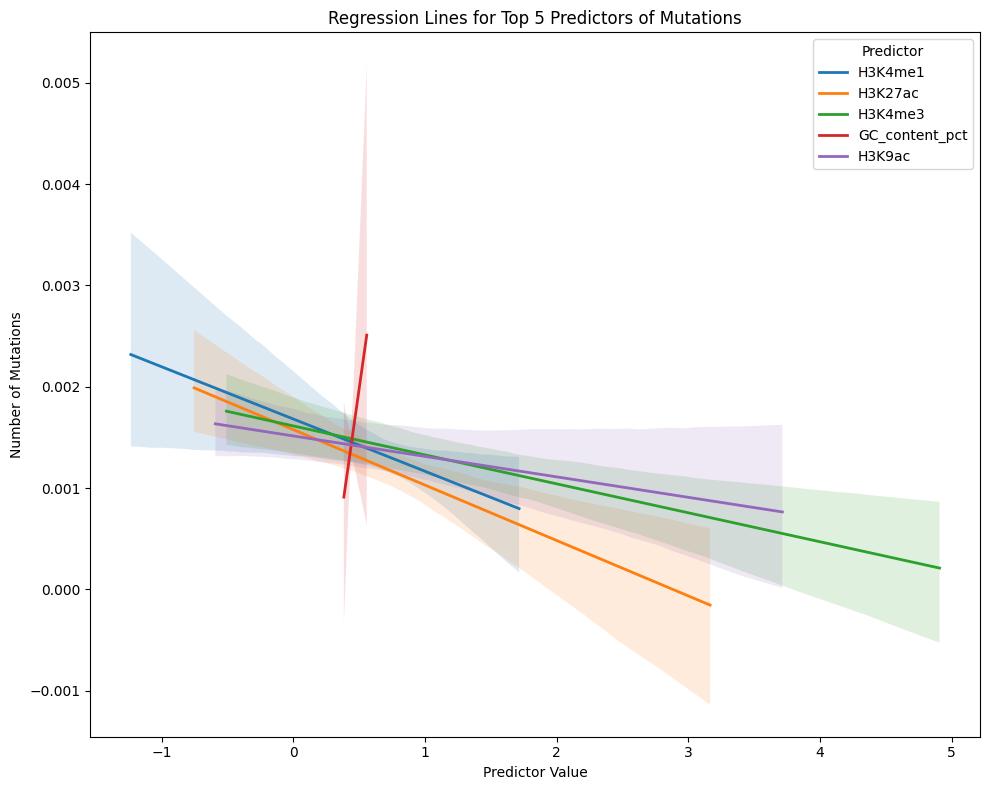

Top 5 significant predictors (p < 0.05):
     H3K4me1  p = 7.09e-06
     H3K27ac  p = 9.25e-06
     H3K4me3  p = 5.16e-04
  GC_content_pct  p = 3.36e-02
      H3K9ac  p = 4.73e-02

Full model summary:
                            OLS Regression Results                            
Dep. Variable:              Mutations   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     4.506
Date:                Thu, 24 Jul 2025   Prob (F-statistic):           2.24e-09
Time:                        16:09:11   Log-Likelihood:                 3107.7
No. Observations:                 719   AIC:                            -6177.
Df Residuals:                     700   BIC:                            -6090.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
         

In [3]:

# --- Configuration ---------------------------------------------------------

# Paths
DATA_PATH = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
FIGURE_DIR = Path.cwd() / "Figures"
FIGURE_FILE = FIGURE_DIR / "af1_reg_lines_mutations.png"

# Predictor columns you expect
PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

# --- Load & Filter ---------------------------------------------------------

# 1. Load data
df = pd.read_csv(DATA_PATH)

# 2. Filter for ESN or lethal genes
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)]

# 3. Ensure predictors exist
missing = set(PREDICTORS) - set(df.columns)
if missing:
    raise ValueError(f"The following predictors are missing from the data: {missing}")

# 4. Drop rows with NaNs in any predictor or in 'Mutations'
df = df.dropna(subset=PREDICTORS + ["Mutations"])


# --- Regression ------------------------------------------------------------

# 5. Prepare X and y
X = df[PREDICTORS]
X = sm.add_constant(X)        # adds intercept
y = df["Mutations"]

# 6. Fit OLS model
model = sm.OLS(y, X).fit()

# 7. Identify top 5 significant predictors (p < 0.05)
#    Exclude the intercept ('const')
significant = model.pvalues.drop("const").loc[lambda s: s < 0.05]
top5 = significant.sort_values().head(5).index.tolist()


# --- Plotting --------------------------------------------------------------

# 8. Ensure the Figures directory exists
FIGURE_DIR.mkdir(exist_ok=True)

# 9. Plot regression lines for the top 5 predictors
plt.figure(figsize=(10, 8))
for predictor in top5:
    sns.regplot(
        x=df[predictor],
        y=y,
        label=predictor,
        scatter=False,
        line_kws={"linewidth": 2}
    )

plt.xlabel("Predictor Value")
plt.ylabel("Number of Mutations")
plt.title("Regression Lines for Top 5 Predictors of Mutations")
plt.legend(title="Predictor")
plt.tight_layout()

# 10. Save the figure
plt.savefig(FIGURE_FILE, dpi=300)
plt.show()


# --- Reporting -------------------------------------------------------------

print("Top 5 significant predictors (p < 0.05):")
for pred, pval in significant.loc[top5].items():
    print(f"  {pred:>10s}  p = {pval:.2e}")

print("\nFull model summary:")
print(model.summary())


In [4]:
df.Mutations.describe()

count    719.000000
mean       0.001489
std        0.003394
min        0.000000
25%        0.000000
50%        0.000625
75%        0.001789
max        0.063272
Name: Mutations, dtype: float64

In [11]:
# --- Prepare top‑5 predictors summary -------------------------------------

# Build a DataFrame with predictor name, coefficient and p‑value
top5_summary_df = pd.DataFrame({
    "Predictor": top5,
    "Coefficient": model.params[top5].values,
    "p-value": model.pvalues[top5].values
})

# Round numbers (optional)
top5_summary_df["Coefficient"] = top5_summary_df["Coefficient"].round(4)
top5_summary_df["p-value"]     = top5_summary_df["p-value"].apply(lambda p: f"{p:.2e}")

# Sort by ascending p‑value and reset the index
top5_summary_df = (
    top5_summary_df
    .sort_values("p-value")
    .reset_index(drop=True)
)

# Display the result
top5_summary_df


,Predictor,Coefficient,p-value
0,GC_content_pct,0.0172,3.36e-02
1,H3K9ac,0.0011,4.73e-02
2,H3K4me3,-0.0013,5.16e-04
3,H3K4me1,-0.0019,7.09e-06
4,H3K27ac,-0.0020,9.25e-06


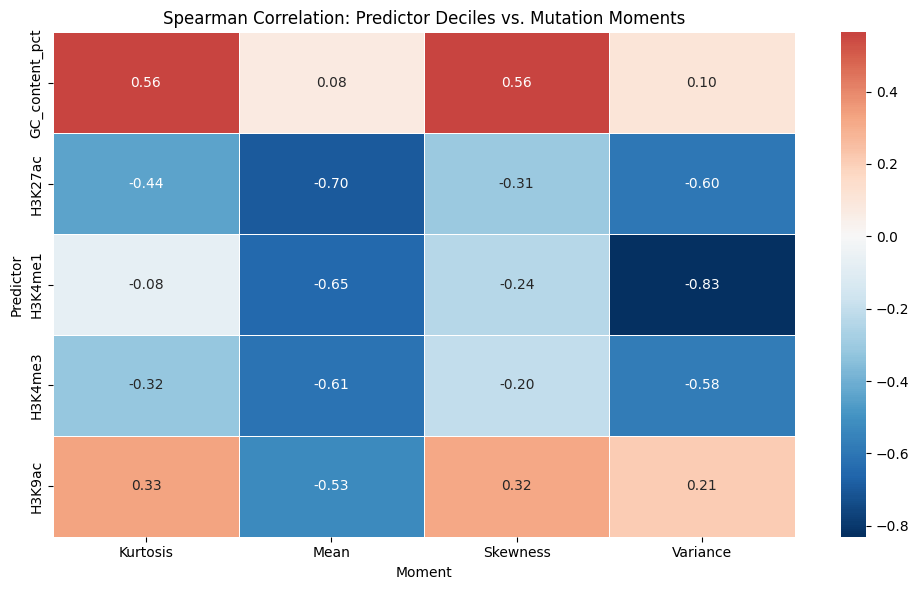

In [16]:

# 1. Set up output path
FIG_DIR  = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True)
FIG_PATH = FIG_DIR / "af2_modifiers_mutations_m.png"

# 2. Copy filtered data
df_binned = df.copy()

# 3. Compute Mutation moments by decile for each top predictor
records = []
for predictor in top5:
    decile_col = f"{predictor}_decile"
    # Create decile bins (0–9), drop duplicate-edge bins if any
    df_binned[decile_col] = pd.qcut(
        df_binned[predictor], 
        q=10, 
        labels=False, 
        duplicates="drop"
    )
    # Aggregate moments in one go
    for decile, subset in df_binned.groupby(decile_col)["Mutations"]:
        records.append({
            "Predictor": predictor,
            "Decile":    int(decile),
            "Mean":      subset.mean(),
            "Variance":  subset.var(ddof=1),
            "Skewness":  skew(subset),
            "Kurtosis":  kurtosis(subset)
        })

moments_df = pd.DataFrame.from_records(records)

# 4. Compute Spearman correlations between decile and each moment
spearman_records = []
for predictor in top5:
    sub = moments_df[moments_df["Predictor"] == predictor]
    for moment in ["Mean", "Variance", "Skewness", "Kurtosis"]:
        rho, pval = spearmanr(sub["Decile"], sub[moment])
        spearman_records.append({
            "Predictor":    predictor,
            "Moment":       moment,
            "Spearman Rho": rho,
            "p-value":      pval
        })

spearman_df = pd.DataFrame.from_records(spearman_records)

# 5. Pivot and plot the heatmap
pivot = spearman_df.pivot(index="Predictor", columns="Moment", values="Spearman Rho")

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cmap="RdBu_r" 
)
plt.title("Spearman Correlation: Predictor Deciles vs. Mutation Moments")
plt.tight_layout()

# 6. Save & show
plt.savefig(FIG_PATH, dpi=300)
plt.show()


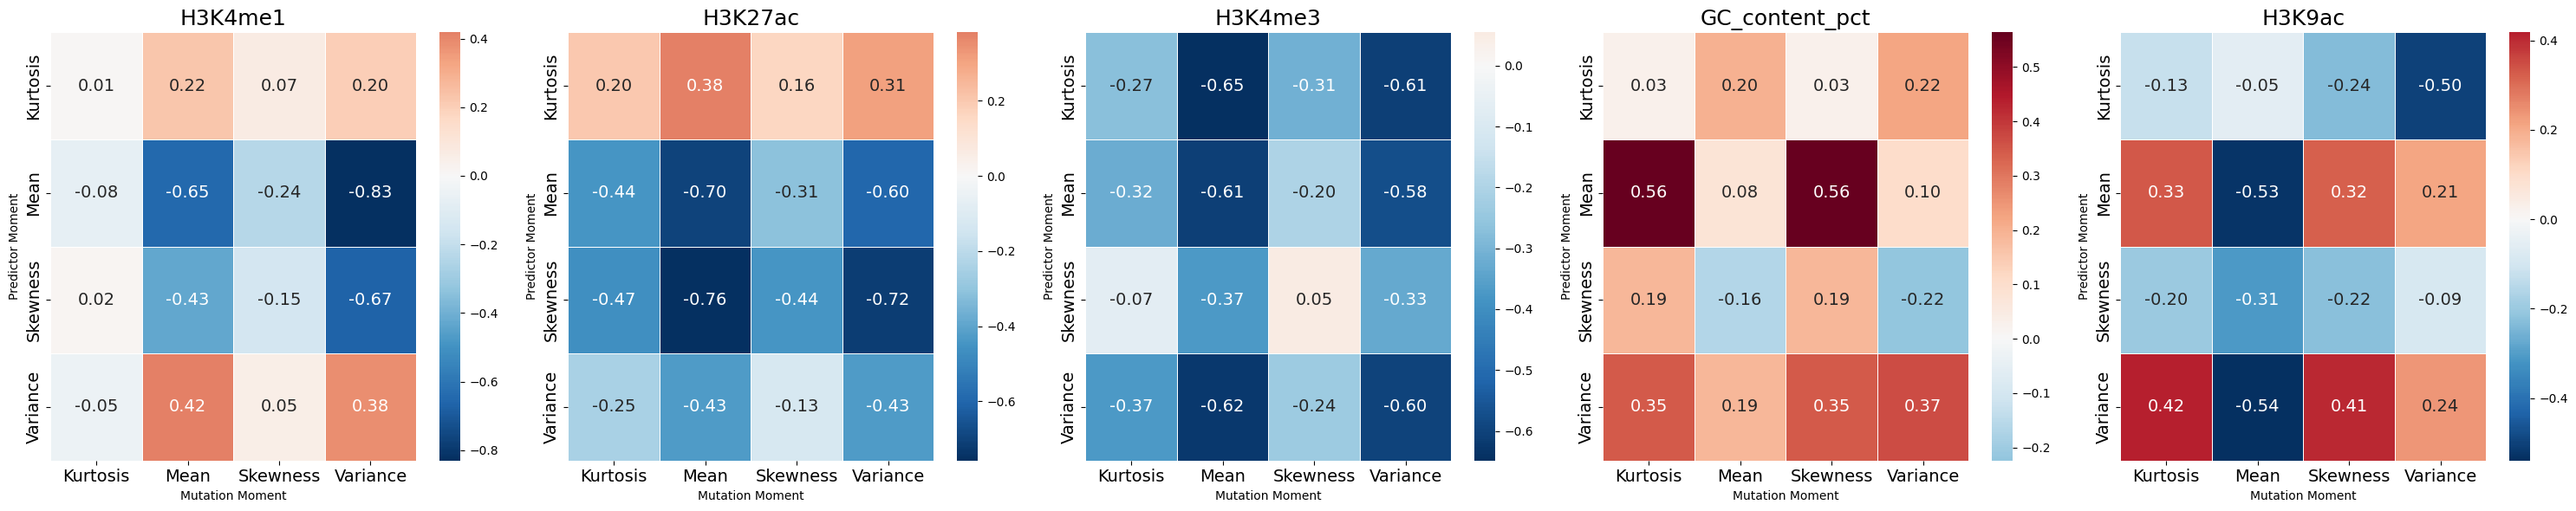

In [18]:
# --- Configuration ---------------------------------------------------------
FIG_DIR  = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True)
FIG_PATH = FIG_DIR / "af3_predictor_mutation_moments.png"

# --- Build the moment correlation matrix ----------------------------------

records = []
for predictor in top5:
    # copy and bin into deciles
    temp = df.copy()
    temp['decile'] = pd.qcut(
        temp[predictor],
        q=10,
        labels=False,
        duplicates='drop'
    )

    # gather moments per decile
    moments = []
    for dec in sorted(temp['decile'].dropna().unique()):
        grp = temp[temp['decile'] == dec]['Mutations']
        pred_grp = temp[temp['decile'] == dec][predictor]
        if len(grp) < 3 or pred_grp.nunique() < 2:
            continue

        moments.append({
            'Decile':      dec,
            'Pred_Mean':   pred_grp.mean(),
            'Pred_Variance': pred_grp.var(ddof=1),
            'Pred_Skewness': pred_grp.skew(),
            'Pred_Kurtosis': pred_grp.kurt(),
            'Mut_Mean':     grp.mean(),
            'Mut_Variance': grp.var(ddof=1),
            'Mut_Skewness': grp.skew(),
            'Mut_Kurtosis': grp.kurt()
        })

    df_mom = pd.DataFrame(moments)

    # compute Spearman for each Pred_* vs Mut_*
    for pm in ['Mean', 'Variance', 'Skewness', 'Kurtosis']:
        for mm in ['Mean', 'Variance', 'Skewness', 'Kurtosis']:
            x = df_mom[f'Pred_{pm}']
            y = df_mom[f'Mut_{mm}']
            if x.nunique() > 1 and y.nunique() > 1:
                rho, _ = spearmanr(x, y)
                records.append({
                    'Predictor':        predictor,
                    'Predictor Moment': pm,
                    'Mutation Moment':  mm,
                    'Spearman Rho':     rho
                })

final_df = pd.DataFrame.from_records(records)

# --- Plot 1×N heatmaps -----------------------------------------------------
predictors = final_df['Predictor'].unique()
n = len(predictors)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)

# use red→blue diverging palette
cmap = "RdBu_r"

for i, predictor in enumerate(predictors):
    ax = axes[0, i]
    sub = final_df[final_df['Predictor'] == predictor]
    pivot = sub.pivot(
        index='Predictor Moment',
        columns='Mutation Moment',
        values='Spearman Rho'
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        center=0,
        cmap=cmap,
        linewidths=0.5,
        annot_kws={'fontsize': 14},
        ax=ax
    )
    ax.set_title(predictor, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300)
plt.show()


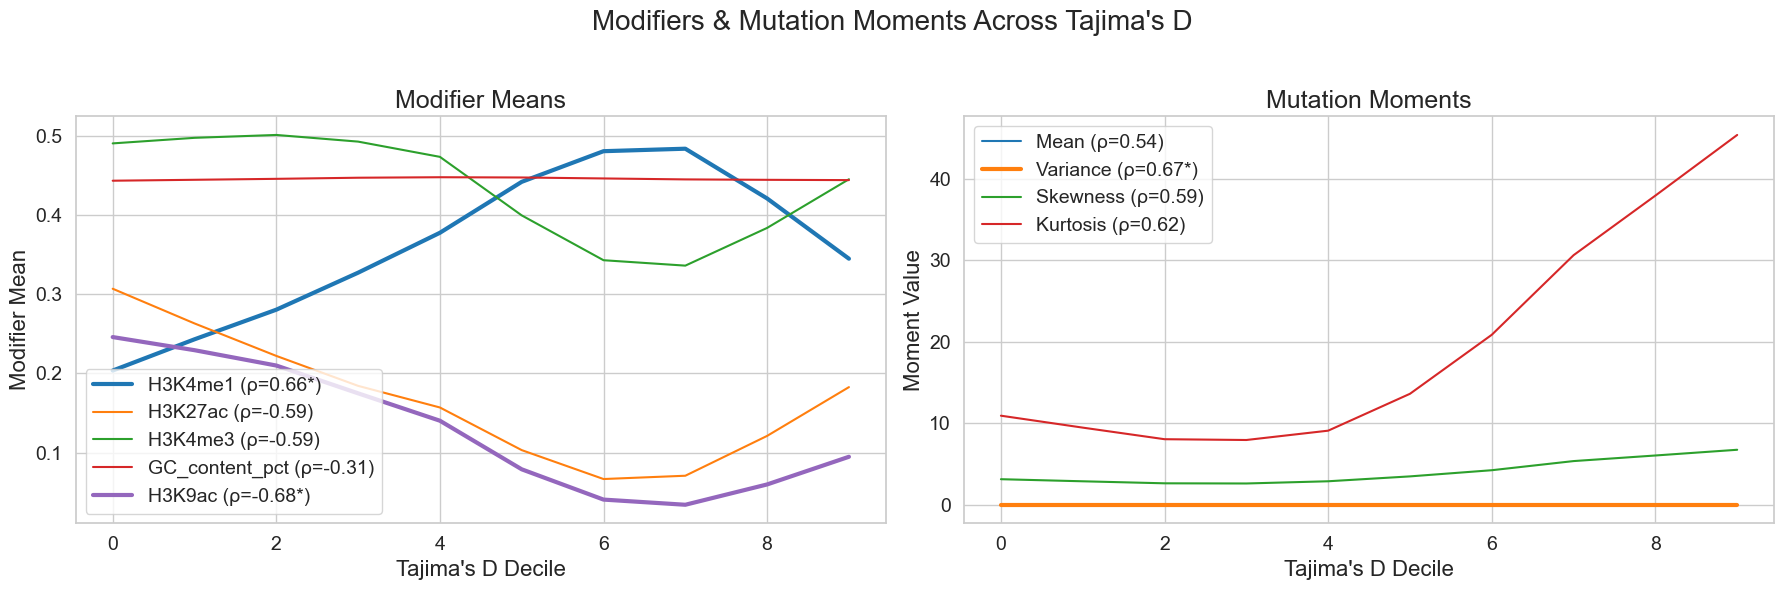

In [5]:
# --- Load & filter ---------------------------------------------------------
data_path = Path.home() / "Documents/GitHub/Random_Modifier/data/gene_level_data.csv"
df = pd.read_csv(data_path)
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)]

modifiers = ["H3K4me1", "H3K27ac", "H3K4me3", "GC_content_pct", "H3K9ac"]
req_cols  = modifiers + ["Mutations", "TajimasD"]
df = df.dropna(subset=req_cols)

# --- Decile & invert for selection strength -------------------------------
df["TajimasD_decile"] = pd.qcut(df["TajimasD"], 10, labels=False, duplicates="drop")
max_dec = df["TajimasD_decile"].max()
df["Sel_decile"] = max_dec - df["TajimasD_decile"]    # 0 = weakest, 9 = strongest

# --- Summarize by selection decile ----------------------------------------
rows = []
for sel in sorted(df["Sel_decile"].unique()):
    sub = df[df["Sel_decile"] == sel]
    entry = {"Sel_decile": sel}
    for mod in modifiers:
        entry[f"{mod}_mean"] = sub[mod].mean()
    muts = sub["Mutations"]
    entry["Mutations_mean"] = muts.mean()
    entry["Mutations_var"]  = muts.var(ddof=1)
    entry["Mutations_skew"] = muts.skew()
    entry["Mutations_kurt"]= kurtosis(muts)
    rows.append(entry)
summary_df = pd.DataFrame(rows)

# --- Spearman correlations -----------------------------------------------
mod_corrs = {
    mod: spearmanr(summary_df["Sel_decile"], summary_df[f"{mod}_mean"])
    for mod in modifiers
}
mom_cols = {
    "Mean":     "Mutations_mean",
    "Variance": "Mutations_var",
    "Skewness": "Mutations_skew",
    "Kurtosis": "Mutations_kurt"
}
mut_corrs = {
    name: spearmanr(summary_df["Sel_decile"], summary_df[col])
    for name, col in mom_cols.items()
}

# --- Plotting -------------------------------------------------------------
sns.set(style="whitegrid")
FIG_DIR  = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True)
FIG_PATH = FIG_DIR / "af4_tajimas_trends.png"

# Use a bold, distinct 10‑color palette
mod_pal = sns.color_palette("tab10", n_colors=len(modifiers))
mom_pal = sns.color_palette("tab10", n_colors=len(mom_cols))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# 1) Modifier trends
for i, mod in enumerate(modifiers):
    rho, p = mod_corrs[mod]
    star   = "*" if p < 0.05 else ""
    label  = f"{mod} (ρ={rho:.2f}{star})"
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[f"{mod}_mean"],
        ax=axes[0],
        lowess=True,
        scatter=False,
        line_kws={"lw": 3 if p < 0.05 else 1.5},
        color=mod_pal[i],
        label=label
    )
axes[0].set_title("Modifier Means", fontsize=18)
axes[0].set_xlabel("Tajima's D Decile", fontsize=16)
axes[0].set_ylabel("Modifier Mean", fontsize=16)
axes[0].legend(fontsize=14)
axes[0].tick_params(labelsize=14)

# 2) Mutation‑moment trends
for i, (name, col) in enumerate(mom_cols.items()):
    rho, p = mut_corrs[name]
    star   = "*" if p < 0.05 else ""
    label  = f"{name} (ρ={rho:.2f}{star})"
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[col],
        ax=axes[1],
        lowess=True,
        scatter=False,
        line_kws={"lw": 3 if p < 0.05 else 1.5},
        color=mom_pal[i],
        label=label
    )
axes[1].set_title("Mutation Moments", fontsize=18)
axes[1].set_xlabel("Tajima's D Decile", fontsize=16)
axes[1].set_ylabel("Moment Value", fontsize=16)
axes[1].legend(fontsize=14)
axes[1].tick_params(labelsize=14)

plt.suptitle("Modifiers & Mutation Moments Across Tajima's D", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- Save & show ----------------------------------------------------------
plt.savefig(FIG_PATH, dpi=300)
plt.show()


In [6]:
# 1. Load & filter data
data_path = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
df = pd.read_csv(data_path)
df = df[(df["essentiality"] == "ESN") | (df["lethal"] == True)]

modifiers = ["H3K4me1", "H3K27ac", "H3K4me3", "GC_content_pct", "H3K9ac"]
required = modifiers + ["Mutations", "TajimasD"]
df = df.dropna(subset=required)

# 2. Compute Tajima’s D deciles and invert for selection strength
df["TajimasD_decile"] = pd.qcut(df["TajimasD"], 10, labels=False, duplicates="drop")
max_dec = df["TajimasD_decile"].max()
df["Sel_decile"] = max_dec - df["TajimasD_decile"]  # 0=weak, 9=strong

# 3. Summarize by selection decile
rows = []
for sel in sorted(df["Sel_decile"].unique()):
    sub = df[df["Sel_decile"] == sel]
    entry = {"Sel_decile": sel}
    # modifier means
    for mod in modifiers:
        entry[f"{mod}_mean"] = sub[mod].mean()
    # mutation moments
    muts = sub["Mutations"]
    entry["Mutations_mean"] = muts.mean()
    entry["Mutations_var"]  = muts.var(ddof=1)
    entry["Mutations_skew"] = muts.skew()
    entry["Mutations_kurt"] = kurtosis(muts)
    rows.append(entry)
summary_df = pd.DataFrame(rows)

# 4. Compute Spearman ρ and p-values for modifiers
mod_results = []
for mod in modifiers:
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[f"{mod}_mean"])
    mod_results.append({
        "Modifier": mod,
        "Spearman ρ": rho,
        "p-value": p
    })
mod_results_df = pd.DataFrame(mod_results)

# 5. Compute Spearman ρ and p-values for mutation moments
mom_names = {
    "Mean": "Mutations_mean",
    "Variance": "Mutations_var",
    "Skewness": "Mutations_skew",
    "Kurtosis": "Mutations_kurt"
}
mom_results = []
for name, col in mom_names.items():
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[col])
    mom_results.append({
        "Moment": name,
        "Spearman ρ": rho,
        "p-value": p
    })
mom_results_df = pd.DataFrame(mom_results)

# 6. Display the exact trends
print("Modifier trends (Spearman correlation with selection strength):")
print(mod_results_df.to_string(index=False, float_format="{:.3f}".format))

print("\nMutation‐moment trends (Spearman correlation with selection strength):")
print(mom_results_df.to_string(index=False, float_format="{:.3f}".format))


Modifier trends (Spearman correlation with selection strength):
      Modifier  Spearman ρ  p-value
       H3K4me1       0.661    0.038
       H3K27ac      -0.588    0.074
       H3K4me3      -0.588    0.074
GC_content_pct      -0.309    0.385
        H3K9ac      -0.685    0.029

Mutation‐moment trends (Spearman correlation with selection strength):
  Moment  Spearman ρ  p-value
    Mean       0.539    0.108
Variance       0.673    0.033
Skewness       0.588    0.074
Kurtosis       0.624    0.054
